E-Commerce Customer Churn

 1. Project Overview

This project focuses on analyzing customer churn in an e-commerce business.

The main objective is to understand customer behavior, identify factors associated with churn, and generate useful business insights that can help improve customer retention.

2. Dataset Overview

The dataset contains customer-level information related to demographics, purchasing behavior, engagement, customer experience, marketing activity, and customer value.

The initial dataset contains 50,000 rows and 25 columns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("ecommerce_customer_churn_dataset.csv")

print("Dataset loaded successfully.")
#An f-string (formatted string literal in Python) that inserts the calculated row count directly into the text.
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())

Dataset loaded successfully.
Rows: 50000
Columns: 25


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Initial inspection was performed using:

    head()
    info()
    describe()
    shape
    dtypes


In [2]:
print("Shape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset information:")
df.info()

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Shape: (50000, 25)

Data types:


,Data Type
Age,float64
Gender,object
Country,object
City,object
Membership_Years,float64
Login_Frequency,float64
Session_Duration_Avg,float64
Pages_Per_Session,float64
Cart_Abandonment_Rate,float64
Wishlist_Items,float64



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,47505.0,NaN,NaN,NaN,37.802968,11.834668,5.0,29.0,38.0,46.0,200.0
Gender,50000,3,Female,25116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,50000,8,USA,17384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,50000,40,Houston,3549,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership_Years,50000.0,NaN,NaN,NaN,2.984009,2.059105,0.1,1.4,2.5,4.0,10.0
Login_Frequency,50000.0,NaN,NaN,NaN,11.62466,7.810657,0.0,6.0,11.0,17.0,46.0
Session_Duration_Avg,46601.0,NaN,NaN,NaN,27.660754,10.871013,1.0,19.7,26.8,34.7,75.6
Pages_Per_Session,47000.0,NaN,NaN,NaN,8.737811,3.77822,1.0,6.0,8.4,11.2,24.1
Cart_Abandonment_Rate,50000.0,NaN,NaN,NaN,57.079973,16.282723,0.0,46.4,58.1,68.7,143.74335
Wishlist_Items,46000.0,NaN,NaN,NaN,4.298391,3.189754,0.0,2.0,4.0,6.0,28.0


The purpose of the initial inspection was to understand the structure and quality of the dataset before performing any transformation.
    
Handling Missing Values

Missing values were identified using:
df.isnull().sum()

In [3]:
quality = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Unique_Values": df.nunique(),
    "Data_Type"    :df.dtypes
}).sort_values("Missing_Count", ascending=False)
display(quality)

,Missing_Count,Unique_Values,Data_Type
Social_Media_Engagement_Score,6000,972,float64
Credit_Balance,5500,5234,float64
Mobile_App_Usage,5000,540,float64
Returns_Rate,4491,394,float64
Wishlist_Items,4000,25,float64
Discount_Usage_Rate,3500,1727,float64
Product_Reviews_Written,3500,18,float64
Session_Duration_Avg,3399,658,float64
Days_Since_Last_Purchase,3000,235,float64
Pages_Per_Session,3000,224,float64


Different methods were used depending on the type of variable.

* For numerical variables, median imputation was used where appropriate because the median is less affected by extreme values.
* For rate and monetary variables, invalid values were first converted to missing values where necessary and then handled using median imputation.
* Numerical columns were converted to numeric format where required:

In [4]:
#Age should be within a reasonable range

df.loc[~df["Age"].between(18, 100), "Age"] = np.nan
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].astype(int)

df["Session_Duration_Avg"] = df["Session_Duration_Avg"].fillna(df["Session_Duration_Avg"].median())
df["Pages_Per_Session"] = df["Pages_Per_Session"].fillna(df["Pages_Per_Session"].median())

df["Wishlist_Items"] = pd.to_numeric(df["Wishlist_Items"], errors="coerce")
df["Wishlist_Items"] = df["Wishlist_Items"].fillna(df["Wishlist_Items"].median())
df["Wishlist_Items"] = df["Wishlist_Items"].astype(int)
##df[df["Total_Purchases"] < 0]
#Purchase counts cannot be negative.
(df["Total_Purchases"] < 0).sum()
df.loc[df["Total_Purchases"] < 0, "Total_Purchases"] = np.nan
df["Total_Purchases"] = df["Total_Purchases"].fillna(df["Total_Purchases"].median())
df["Total_Purchases"]=df["Total_Purchases"].astype(int)

df["Days_Since_Last_Purchase"] = pd.to_numeric(df["Days_Since_Last_Purchase"], errors="coerce")
df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].fillna(df["Days_Since_Last_Purchase"].median())
df["Days_Since_Last_Purchase"] = df["Days_Since_Last_Purchase"].astype(int)

#Percentage/rate variables should normally fall between 0 and 100.
df.loc[~df["Discount_Usage_Rate"].between(0, 100),"Discount_Usage_Rate"] = np.nan
df["Discount_Usage_Rate"] = pd.to_numeric(df["Discount_Usage_Rate"], errors="coerce")
df["Discount_Usage_Rate"] = df["Discount_Usage_Rate"].fillna(df["Discount_Usage_Rate"].median())

df.loc[~df["Returns_Rate"].between(0, 100),"Returns_Rate"] = np.nan
df["Returns_Rate"] = pd.to_numeric(df["Returns_Rate"], errors="coerce")
df["Returns_Rate"] = df["Returns_Rate"].fillna(df["Returns_Rate"].median())

df.loc[~df["Email_Open_Rate"].between(0, 100),"Email_Open_Rate"] = np.nan
df["Email_Open_Rate"] = pd.to_numeric(df["Email_Open_Rate"], errors="coerce")
df["Email_Open_Rate"] = df["Email_Open_Rate"].fillna(df["Email_Open_Rate"].median())


#Customer service calls and review counts cannot be negative.
df["Customer_Service_Calls"] = pd.to_numeric(df["Customer_Service_Calls"],errors="coerce")
df.loc[df["Customer_Service_Calls"] < 0,"Customer_Service_Calls"] = np.nan
df["Customer_Service_Calls"] = df["Customer_Service_Calls"].fillna(df["Customer_Service_Calls"].median())
df["Customer_Service_Calls"] = df["Customer_Service_Calls"].astype(int)

df["Product_Reviews_Written"] = pd.to_numeric(df["Product_Reviews_Written"],errors="coerce")
df.loc[df["Product_Reviews_Written"] < 0,"Product_Reviews_Written"] = np.nan
df["Product_Reviews_Written"] = df["Product_Reviews_Written"].fillna(df["Product_Reviews_Written"].median())
df["Product_Reviews_Written"] = df["Product_Reviews_Written"].astype(int)

df["Social_Media_Engagement_Score"] = pd.to_numeric(df["Social_Media_Engagement_Score"],errors="coerce")
df.loc[df["Social_Media_Engagement_Score"] < 0,"Social_Media_Engagement_Score"] = np.nan
df["Social_Media_Engagement_Score"] = df["Social_Media_Engagement_Score"].fillna(df["Social_Media_Engagement_Score"].median())

df["Mobile_App_Usage"] = pd.to_numeric(df["Mobile_App_Usage"],errors="coerce")
df.loc[df["Mobile_App_Usage"] < 0,"Mobile_App_Usage"] = np.nan
df["Mobile_App_Usage"] = df["Mobile_App_Usage"].fillna(df["Mobile_App_Usage"].median())

df["Payment_Method_Diversity"] = pd.to_numeric(df["Payment_Method_Diversity"],errors="coerce")
df.loc[df["Payment_Method_Diversity"] < 0,"Payment_Method_Diversity"] = np.nan
df["Payment_Method_Diversity"] = df["Payment_Method_Diversity"].fillna(df["Payment_Method_Diversity"].median())
df["Payment_Method_Diversity"] = df["Payment_Method_Diversity"].astype(int)

df["Credit_Balance"] = pd.to_numeric(df["Credit_Balance"],errors="coerce")
df.loc[df["Credit_Balance"] < 0,"Credit_Balance"] = np.nan
df["Credit_Balance"] = df["Credit_Balance"].fillna(df["Credit_Balance"].median())

df["Churned"] = df["Churned"].astype(int)

Duplicate records were checked using: df.duplicated().any()

In [5]:
df.duplicated().any()
df.duplicated().sum()

np.int64(0)

Derived Columns:
    
Derived columns were created from existing variables to make the analysis more meaningful.

Derived Age_Group Column

In [6]:
#Customers were divided into different age categories.
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[17, 40, 60, 75, 100],
    labels=["Young Adult", "Middle-Aged Adult", "Older Adult", "Elderly"]
)
df[["Age", "Age_Group"]].head(100)

,Age,Age_Group
0,43,Middle-Aged Adult
1,36,Young Adult
2,45,Middle-Aged Adult
3,56,Middle-Aged Adult
4,35,Young Adult
...,...,...
95,20,Young Adult
96,41,Middle-Aged Adult
97,41,Middle-Aged Adult
98,38,Young Adult


Derived Customer_Activity_Status Column

In [7]:
#Combine Days_Since_Last_Purchase with recent activity:
df["Customer_Activity_Status"] = pd.cut(
    df["Days_Since_Last_Purchase"],
    bins=[-1, 30, 90, 180, float("inf")],
    labels=["Active", "At Risk", "Inactive", "Dormant"]
)
df[["Days_Since_Last_Purchase", "Customer_Activity_Status"]].head(100)

,Days_Since_Last_Purchase,Customer_Activity_Status
0,34,At Risk
1,71,At Risk
2,11,Active
3,47,At Risk
4,73,At Risk
...,...,...
95,22,Active
96,30,Active
97,8,Active
98,13,Active


Derived Purchase_Value Column useful for comparing customer spending behavior.

In [8]:
#This estimates the customer's total purchase value based on purchase count × average order value
df["Purchase_Value"] = (df["Total_Purchases"] * df["Average_Order_Value"])
df[["Purchase_Value"]].head(100)

,Purchase_Value
0,852.48
1,1566.55
2,1489.68
3,2209.95
4,4521.60
...,...
95,1251.80
96,575.92
97,1116.83
98,4582.80


Filtering or aggregating data
Filtering was performed to analyze specific customer groups.

In [9]:
#creating a churned customer dataset 
churned_customers = df[df["Churned"] == 1]

churned_customers[["Age", "Gender", "Total_Purchases", "Lifetime_Value", "Churned"]].head()

#print("Number of churned customers:", len(churned_customers))

,Age,Gender,Total_Purchases,Lifetime_Value,Churned
5,35,Male,12,1995.43,1
10,32,Male,5,599.41,1
11,32,Female,5,335.92,1
13,18,Female,11,1083.91,1
21,35,Male,6,644.58,1


In [10]:
high_value = df[df["Lifetime_Value"] > df["Lifetime_Value"].median()]

high_value[["Lifetime_Value"]].head()
#len(high_value)

,Lifetime_Value
2,1289.75
3,2340.92
4,3041.29
5,1995.43
6,3003.57


In [11]:
inactive_customers = df[df["Days_Since_Last_Purchase"] > 180]

inactive_customers[["Days_Since_Last_Purchase"]].head()

,Days_Since_Last_Purchase
1214,199
1339,204
1451,186
2277,200
2307,193


In [12]:
high_cart_abandonment = df[df["Cart_Abandonment_Rate"] > 75]

high_cart_abandonment[["Cart_Abandonment_Rate"]].head()

,Cart_Abandonment_Rate
11,77.2
21,80.9
42,75.1
47,78.4
70,76.0


In [13]:
df["Churned"].value_counts()

Churned
0    35550
1    14450
Name: count, dtype: int64

In [14]:
churn_rate = df["Churned"].mean() * 100

print("Churn Rate:", churn_rate)

Churn Rate: 28.9


In [15]:
df.groupby("Churned")[
    ["Age",
    "Total_Purchases",
    "Average_Order_Value",
    "Days_Since_Last_Purchase",
    "Lifetime_Value",
    "Cart_Abandonment_Rate"]].mean()

,Age,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Lifetime_Value,Cart_Abandonment_Rate
Churned,,,,,,
0,38.500169,13.732518,118.383907,26.541322,1446.805875,54.194460
1,35.992318,11.247266,134.762532,35.966851,1425.423236,64.178935


In [16]:
country_summary = df.groupby("Country").agg(
    Customers=("Churned", "count"),
    Churn_Rate=("Churned", "mean"),
    Avg_Lifetime_Value=("Lifetime_Value", "mean"),
    Avg_Purchases=("Total_Purchases", "mean")
)
country_summary["Churn_Rate"] = (
    country_summary["Churn_Rate"] * 100)
country_summary[["Customers",  "Churn_Rate",  "Avg_Lifetime_Value",  "Avg_Purchases"]].head()

,Customers,Churn_Rate,Avg_Lifetime_Value,Avg_Purchases
Country,,,,
Australia,4061,29.894115,1443.163772,13.025856
Canada,6023,29.354142,1427.204156,12.926615
France,4013,27.286319,1451.532988,13.043359
Germany,4925,28.832487,1447.675927,13.122640
India,3512,29.014806,1458.122170,13.143508


In [17]:
pivot_gender = pd.pivot_table(
    df,
    values="Lifetime_Value",
    index="Gender",
    columns="Churned",
    aggfunc="mean"
)

pivot_gender.columns = ["Retained", "Churned"]

pivot_gender

,Retained,Churned
Gender,,
Female,1449.809253,1423.386189
Male,1443.094491,1428.159110
Other,1461.968789,1411.773993


Graphs

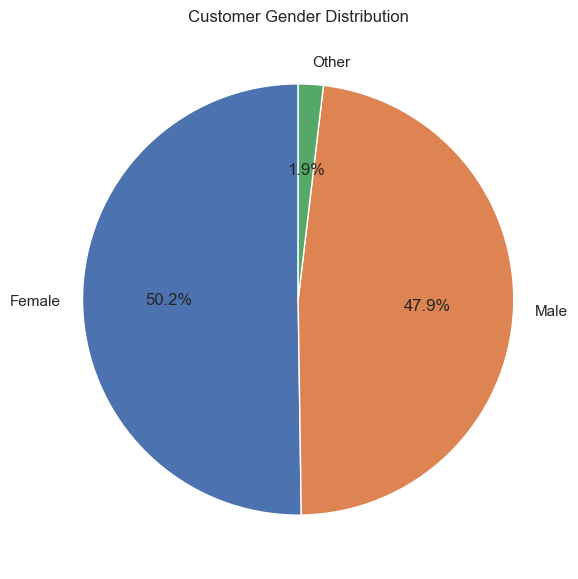

In [18]:
gender_counts = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Gender Distribution")
plt.show()

Pie chart shows the percentage composition of customers by Female, Male and Other.
Analysis type: Univariate categorical analysis.
Business use: Helps understand the demographic composition of the customer base.


C:\Users\Hp\AppData\Local\Temp\ipykernel_1736\1275136541.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Churned", "Churned"])


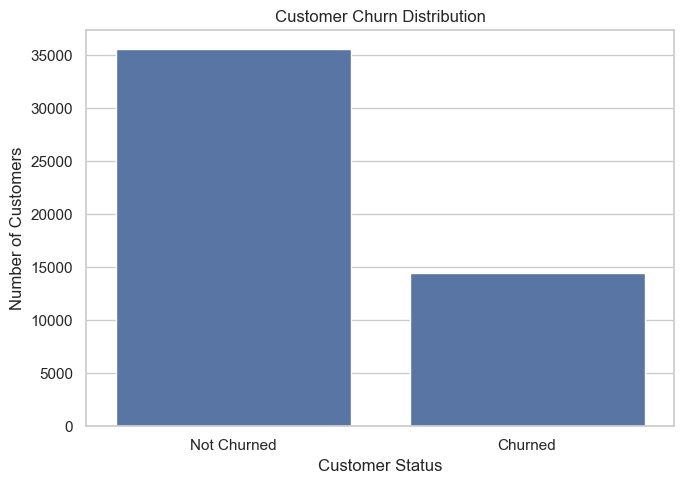

In [19]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Churned")
ax.set_xticklabels(["Not Churned", "Churned"])
plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Countplot shows 35,550 customers are not churned and 14,450 customers are churned.
Overall churn rate: 28.9%.
Business meaning: Nearly 3 out of 10 customers have churned, making retention an important business issue.


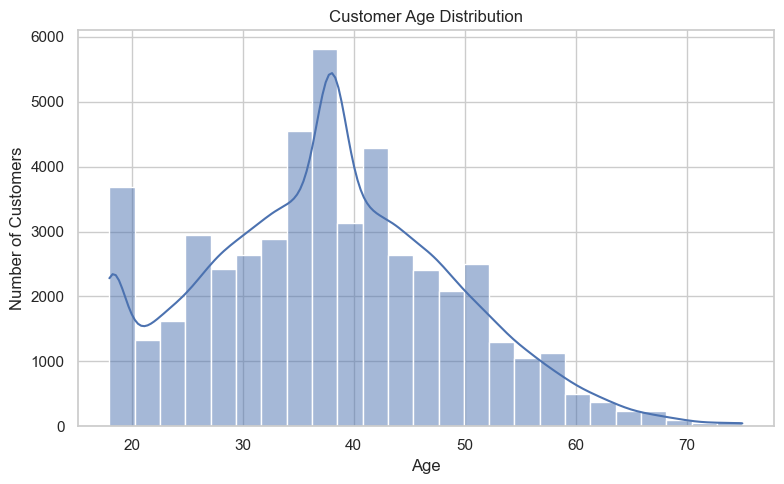

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", bins=25, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

Histogram shows how customers are distributed across age ranges.
Mean age is approximately 37.8 years and median age is 38 years.
Business use: Helps identify the major customer age segments.


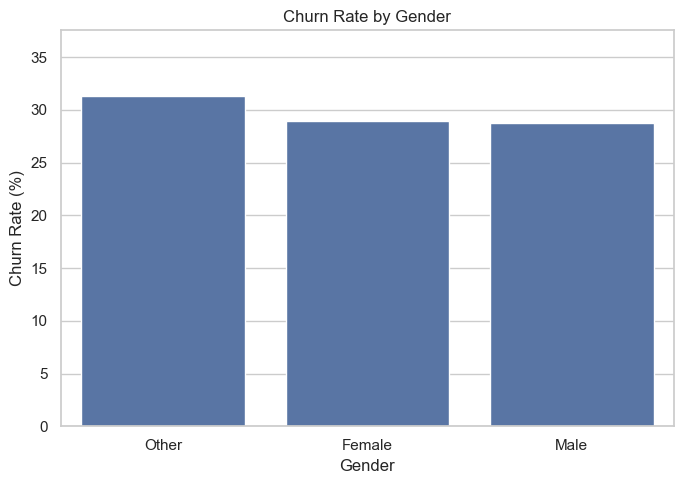

,Churn Rate (%)
Gender,
Other,31.27
Female,28.97
Male,28.73


In [21]:
gender_churn = df.groupby("Gender")["Churned"].mean().sort_values(ascending=False) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=gender_churn.index, y=gender_churn.values)
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, max(gender_churn.values) * 1.2)
plt.tight_layout()
plt.show()

display(gender_churn.round(2).to_frame("Churn Rate (%)"))

Bar chart Compares the percentage of churned customers within each gender.
Business use: Helps identify gender segments with relatively higher churn


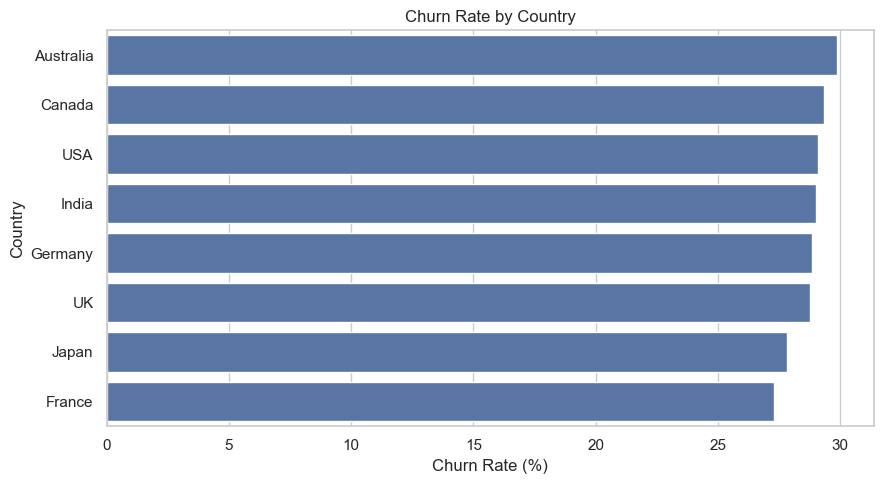

,Churn Rate (%)
Country,
Australia,29.89
Canada,29.35
USA,29.08
India,29.01
Germany,28.83
UK,28.79
Japan,27.83
France,27.29


In [22]:
country_churn = (
    df.groupby("Country")["Churned"]
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(9, 5))
sns.barplot(x=country_churn.values, y=country_churn.index)
plt.title("Churn Rate by Country")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

display(country_churn.round(2).to_frame("Churn Rate (%)"))

In [ ]:
Horizontal Bar chart Identifies geographical differences in customer churn.


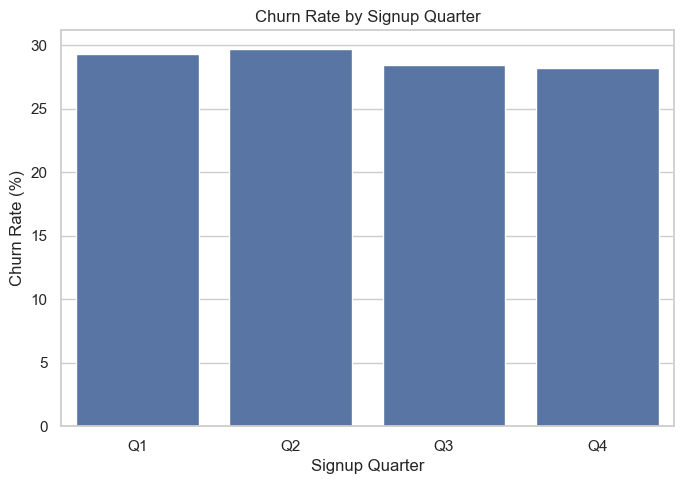

,Churn Rate (%)
Signup_Quarter,
Q1,29.32
Q2,29.67
Q3,28.43
Q4,28.18


In [23]:
quarter_order = ["Q1", "Q2", "Q3", "Q4"]
quarter_churn = df.groupby("Signup_Quarter")["Churned"].mean().reindex(quarter_order) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=quarter_churn.index, y=quarter_churn.values)
plt.title("Churn Rate by Signup Quarter")
plt.xlabel("Signup Quarter")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

display(quarter_churn.round(2).to_frame("Churn Rate (%)"))

Bar chart Compares churn rates based on the quarter in which customers signed up.
Business use: Helps investigate seasonal signup patterns and onboarding differences.



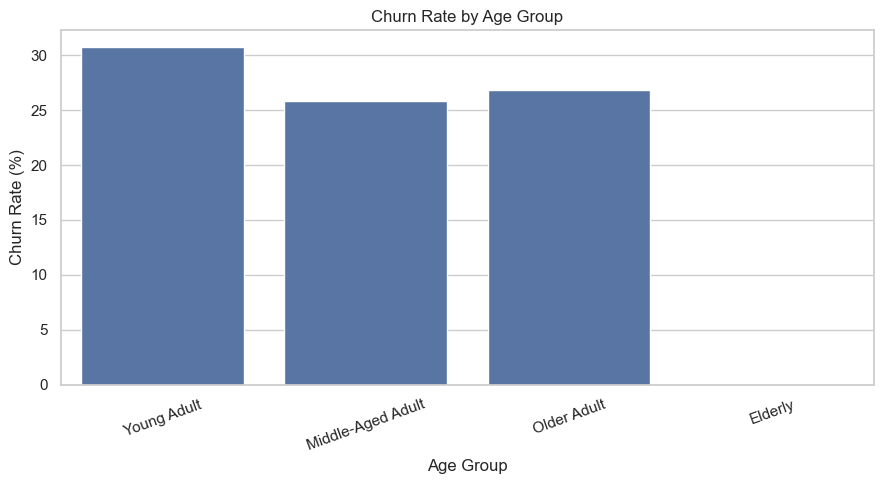

In [24]:
age_churn = df.groupby("Age_Group", observed=True)["Churned"].mean() * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=age_churn.index, y=age_churn.values)
plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Bar Chart Compares churn rates across meaningful age segments.
Business use: Helps identify age groups that may require targeted retention strategies.


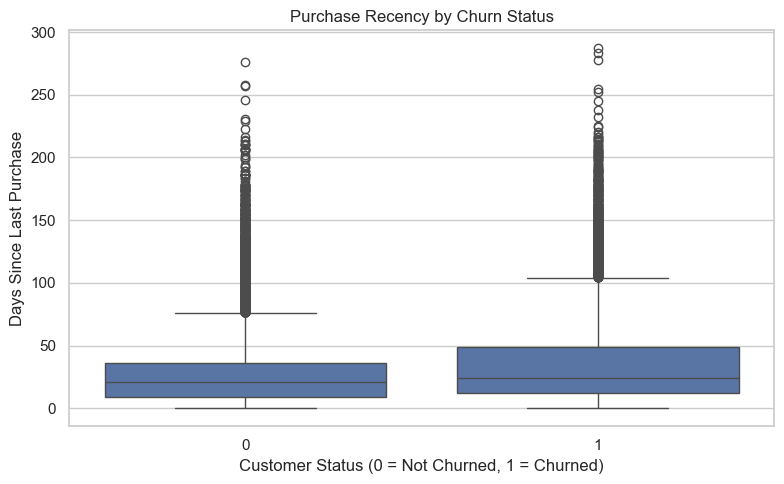

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churned", y="Days_Since_Last_Purchase")
plt.title("Purchase Recency by Churn Status")
plt.xlabel("Customer Status (0 = Not Churned, 1 = Churned)")
plt.ylabel("Days Since Last Purchase")
plt.tight_layout()
plt.show()

Box p[lot shows Churned customers have gone longer without purchasing on average.
Business use: Recent purchase inactivity can be used as a churn-risk signal.


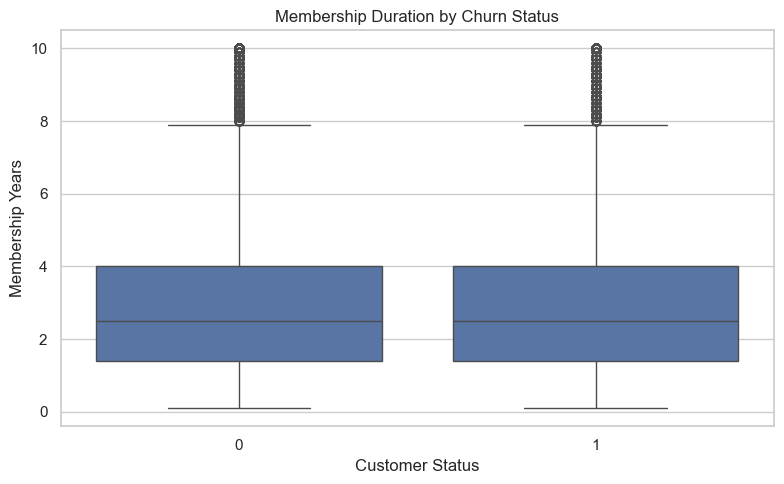

In [26]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churned", y="Membership_Years")
plt.title("Membership Duration by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Membership Years")
plt.tight_layout()
plt.show()

Box plot shows Compares membership-duration distributions between churned and retained customers.
Business use: Helps investigate whether customer tenure is associated with churn.


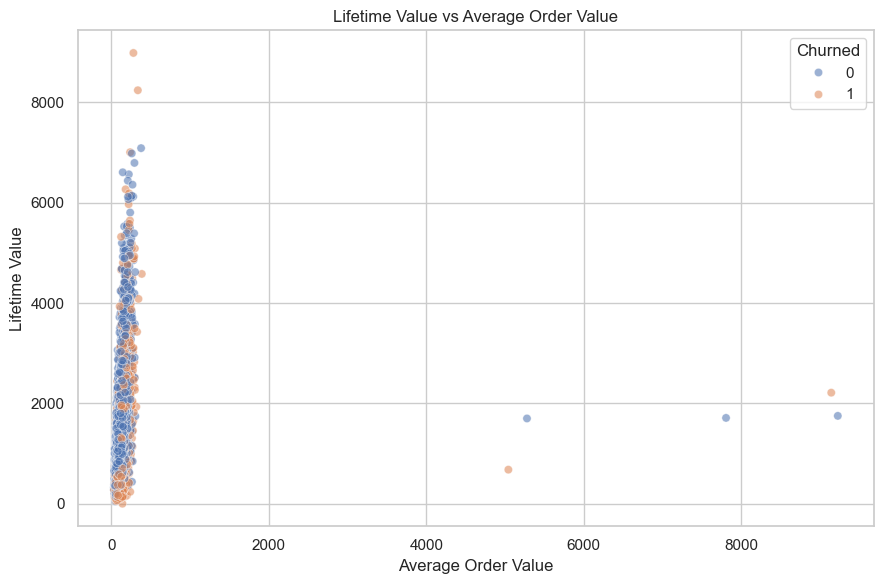

In [27]:
sample = df.sample(min(8000, len(df)), random_state=42)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample,
    x="Average_Order_Value",
    y="Lifetime_Value",
    hue="Churned",
    alpha=0.55
)
plt.title("Lifetime Value vs Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("Lifetime Value")
plt.legend(title="Churned")
plt.tight_layout()
plt.show()

Scatter plot shows examines the relationship between spending per order and customer lifetime value.
Business use: Helps identify spending patterns associated with churn


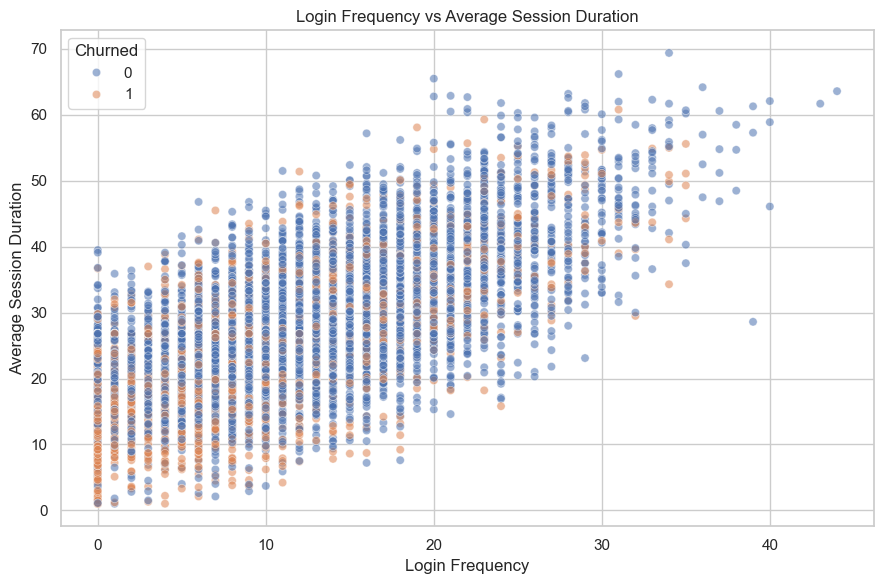

In [28]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=sample,
    x="Login_Frequency",
    y="Session_Duration_Avg",
    hue="Churned",
    alpha=0.55
)
plt.title("Login Frequency vs Average Session Duration")
plt.xlabel("Login Frequency")
plt.ylabel("Average Session Duration")
plt.legend(title="Churned")
plt.tight_layout()
plt.show()

Scatter plot examines customer engagement and its relationship with churn.
Business use: Low-engagement customers may be candidates for re-engagement campaigns.


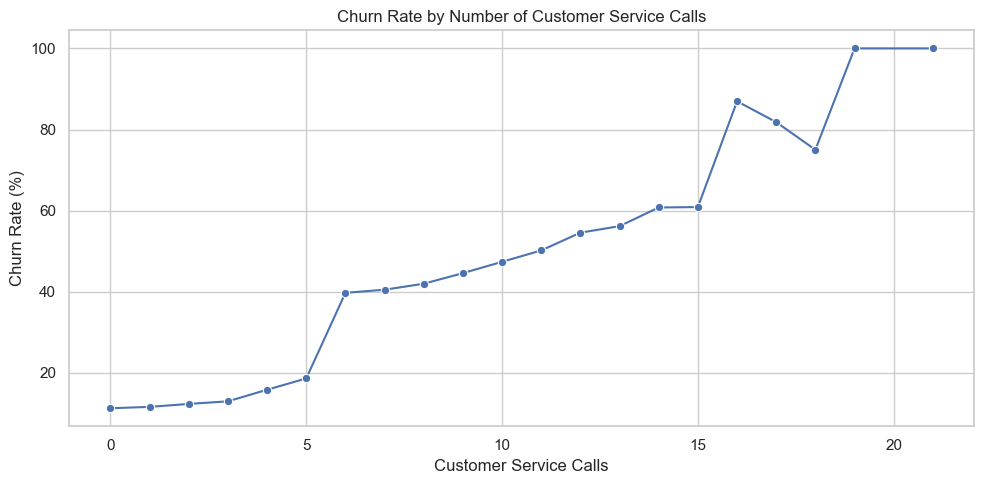

In [29]:
service_churn = df.groupby("Customer_Service_Calls")["Churned"].mean() * 100

plt.figure(figsize=(10, 5))
sns.lineplot(x=service_churn.index, y=service_churn.values, marker="o")
plt.title("Churn Rate by Number of Customer Service Calls")
plt.xlabel("Customer Service Calls")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Line chart examines how churn rate changes as customer service interactions increase.
Important: The graph shows association, not proof that service calls cause churn.
Business use: Helps identify customer-service-related churn patterns.


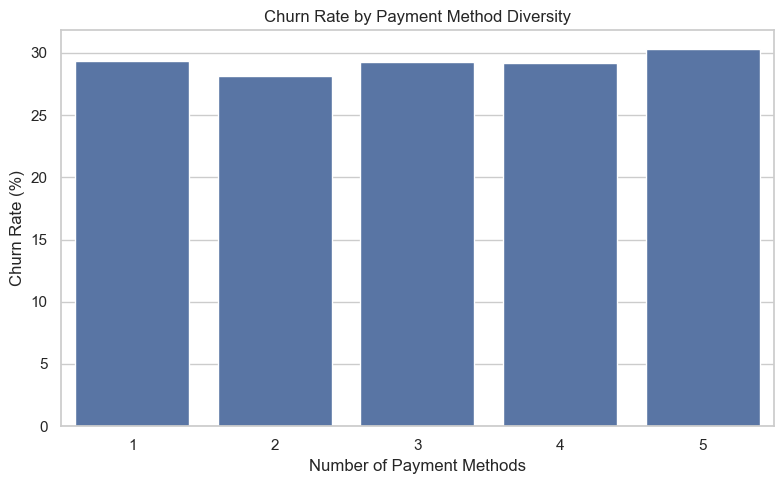

In [30]:
payment_churn = df.groupby("Payment_Method_Diversity")["Churned"].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_churn.index, y=payment_churn.values)
plt.title("Churn Rate by Payment Method Diversity")
plt.xlabel("Number of Payment Methods")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.show()

Bar chart examines how churn rate changes as customer service interactions increase.
Important: The graph shows association, not proof that service calls cause churn.
Business use: Helps identify customer-service-related churn patterns.


Key Insights:

🔴 High-priority insights
1. Overall churn is 28.9%	A significant portion of customers are being lost.
2. Churned customers purchase less frequently	11.25 vs 13.73 average purchases.
3. Churned customers have longer purchase gaps	35.97 vs 26.54 days.
4. Churned customers have higher cart abandonment	64.18% vs 54.19%.
🟠 Important supporting insights
5. Churned customers have higher average order value	134.76 vs 118.38.
6. Churned customers have slightly lower lifetime value	1,425.42 vs 1,446.81.
7. Gender differences are relatively small	Other has the highest churn, but male/female rates are close.
🟡 Lower-priority segmentation insights
8. Australia has the highest country churn rate.
9. Q2 has the highest signup-quarter churn rate.
10. Churned customers are slightly younger on average.


Churn Prevention Strategy:
    
🟢 Active Customers
Loyalty rewards 
Personalized recommendations 
Cross-selling 
Membership benefits 
🟡 At-Risk Customers
Reminder emails 
Personalized offers 
Product recommendations 
Limited-time discounts 
🟠 Inactive Customers
Re-engagement campaigns 
Special discounts 
Free shipping 
New-product notifications 
🔴 Dormant Customers
Win-back campaign 
Strong personalized incentive 
Customer feedback survey 
Final reactivation offer
⭐ High-Value At-Risk Customers
Give this group the highest priority, because losing a valuable customer can have a greater financial impact.



In [ ]:
Final conclusion

The analysis of 50,000 e-commerce customers reveals a 28.9% churn rate.
Churned customers show lower purchase frequency, longer gaps since their last purchase, and higher cart abandonment rates compared with retained
customers. Although churned customers have a higher average order value, their overall lifetime value is slightly lower, indicating that repeated
engagement and purchase frequency are important for long-term customer retention. Demographic factors such as gender, country, age, and signup 
quarter show comparatively smaller differences. Therefore, the business should focus its churn-prevention strategy primarily on behavioral indicators 
such as purchase recency, purchase frequency, cart abandonment, customer engagement, and high-value at-risk customers.
